# Session 9 — Deep Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tech4alltraining/aiml/blob/main/mlai-genai-internship/student/notebooks/session-09-deep-learning.ipynb)

**ML/AI & GenAI Internship** · ANNs · Activations · Losses · Backpropagation from scratch · Optimizers · DL → GenAI

---

## How to use this notebook

**You will build a working neural network in about twenty lines of NumPy** — forward pass, loss, backpropagation and all. Once you have seen those twenty lines, every deep learning framework is just a faster version of them.

| # | Topic |
|---|---|
| 1 | From a neuron to a network |
| 2 | Activation Functions |
| 3 | Loss Functions |
| 4 | Backpropagation and gradient descent |
| 5 | Optimizers |
| 6 | From Deep Learning to Generative AI |

Exercises, MCQs and tasks: [Session 9 guide](../sessions/session-09-deep-learning.md).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
print("ready")

ready


---
# 1. From a neuron to a network

**One neuron does three things:** multiply each input by a weight, add them up with a bias, pass the result through an activation.

```text
  x1 ----w1----\
  x2 ----w2-----> [ sum + bias ] --> [ activation ] --> output
  x3 ----w3----/
```

🧠 **Deciding whether to go out tonight.** *Is it raining?* (weight −5). *Are my friends going?* (+3). *Work tomorrow?* (−2). Add them up; if the total clears your threshold, you go. **That is one neuron.** Your bias is how much you like going out in general.

In [2]:
def neuron(inputs, weights, bias):
    return max(0, np.dot(inputs, weights) + bias)      # ReLU activation

W, B = [-5, 3, -2], 4
print("raining, no friends, work tomorrow :", neuron([1, 0, 1], W, B))
print("dry, friends going, free tomorrow  :", neuron([0, 1, 0], W, B))

raining, no friends, work tomorrow : 0
dry, friends going, free tomorrow  : 7


In [3]:
# Why ONE neuron is not enough: XOR.
from sklearn.linear_model import LogisticRegression

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], float)
y = np.array([0, 1, 1, 0])          # 1 when EXACTLY ONE input is 1

print("  x1  x2  XOR")
for xi, yi in zip(X, y):
    print(f"  {int(xi[0])}   {int(xi[1])}    {yi}")

print("\nlogistic regression :", LogisticRegression().fit(X, y).score(X, y))
print("MLP, 4 hidden units :", MLPClassifier(hidden_layer_sizes=(4,), max_iter=5000,
                                             random_state=1).fit(X, y).score(X, y))
print("\n0.50 on a balanced two-class problem is PURE CHANCE.")
print("The two 1s sit at (0,1) and (1,0) - opposite diagonals. No single")
print("straight line separates them, and one neuron draws one line.")
print("\nTHIS is why hidden layers exist. This exact limitation, published")
print("in 1969, stalled neural network research for over a decade.")

  x1  x2  XOR
  0   0    0
  0   1    1
  1   0    1
  1   1    0

logistic regression : 0.5


MLP, 4 hidden units : 1.0

0.50 on a balanced two-class problem is PURE CHANCE.
The two 1s sit at (0,1) and (1,0) - opposite diagonals. No single
straight line separates them, and one neuron draws one line.

THIS is why hidden layers exist. This exact limitation, published
in 1969, stalled neural network research for over a decade.


In [4]:
# Does ONE hidden neuron suffice? No - it is still one line.
for h in [1, 2, 4, 8]:
    s = MLPClassifier(hidden_layer_sizes=(h,), max_iter=5000, random_state=1).fit(X, y).score(X, y)
    print(f"hidden units = {h:<3} XOR accuracy {s:.2f}")

print("\nhidden_layer_sizes=(16, 8) means TWO hidden layers, of 16 and 8.")
print("Input and output layers are added automatically.")
print("'Deep' learning simply means more than one hidden layer.")
print("There is no other threshold.")

hidden units = 1   XOR accuracy 0.50
hidden units = 2   XOR accuracy 0.50


hidden units = 4   XOR accuracy 1.00
hidden units = 8   XOR accuracy 1.00

hidden_layer_sizes=(16, 8) means TWO hidden layers, of 16 and 8.
Input and output layers are added automatically.
'Deep' learning simply means more than one hidden layer.
There is no other threshold.


---
# 2. Activation Functions

**The activation is what makes a network more than an expensive linear model.**

| Function | Range | Use it |
|---|---|---|
| **ReLU** `max(0, z)` | 0 to ∞ | **Hidden layers — the default** |
| **Sigmoid** | 0 to 1 | Binary output layer |
| **Tanh** | −1 to 1 | Sometimes hidden layers |
| **Softmax** | Sums to 1 | Multi-class output layer |

> **The rule to memorise:** **ReLU everywhere hidden. Sigmoid for one output. Softmax for many.**

In [5]:
def relu(z):    return np.maximum(0, z)
def sigmoid(z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
def softmax(z):
    e = np.exp(z - z.max())         # subtract the max for numerical stability
    return e / e.sum()

z = np.array([-2, -0.5, 0, 0.5, 2])
print("input   ", z)
print("relu    ", relu(z))
print("sigmoid ", sigmoid(z).round(3))
print("tanh    ", np.tanh(z).round(3))
print("\nsoftmax([2.0, 1.0, 0.1]) =", softmax(np.array([2.0, 1.0, 0.1])).round(3),
      " sums to", softmax(np.array([2.0, 1.0, 0.1])).sum())

input    [-2.  -0.5  0.   0.5  2. ]
relu     [0.  0.  0.  0.5 2. ]
sigmoid  [0.119 0.378 0.5   0.622 0.881]
tanh     [-0.964 -0.462  0.     0.462  0.964]

softmax([2.0, 1.0, 0.1]) = [0.659 0.242 0.099]  sums to 1.0


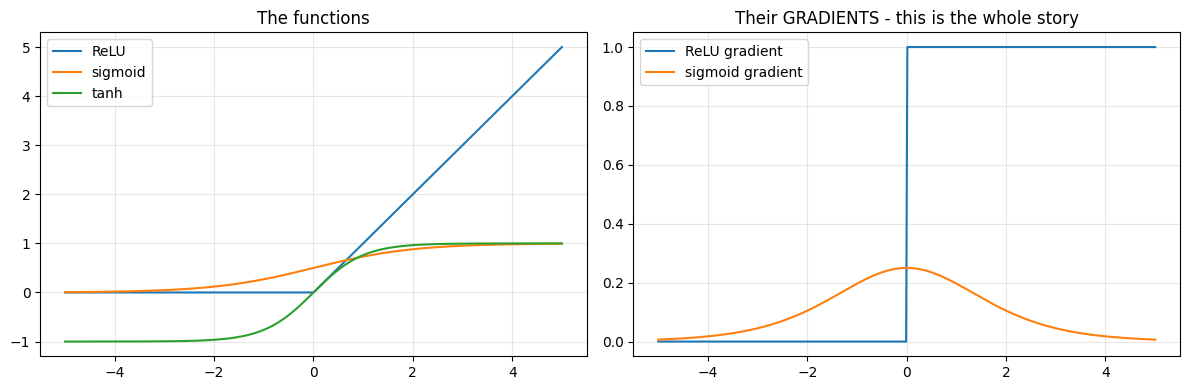

sigmoid's gradient never exceeds 0.250
after 10 stacked layers that is 9.533e-07 - effectively ZERO
ReLU's gradient is exactly 1 for positive inputs: 1^10 = 1.0

That is the vanishing gradient problem, and why deep networks
did not work for years.


In [6]:
# WHY ReLU won: the vanishing gradient problem.
zz = np.linspace(-5, 5, 400)
d_sigmoid = sigmoid(zz) * (1 - sigmoid(zz))
d_relu = (zz > 0).astype(float)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(zz, relu(zz), label="ReLU"); a1.plot(zz, sigmoid(zz), label="sigmoid")
a1.plot(zz, np.tanh(zz), label="tanh"); a1.set_title("The functions")
a1.legend(); a1.grid(alpha=.3)
a2.plot(zz, d_relu, label="ReLU gradient"); a2.plot(zz, d_sigmoid, label="sigmoid gradient")
a2.set_title("Their GRADIENTS - this is the whole story"); a2.legend(); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"sigmoid's gradient never exceeds {d_sigmoid.max():.3f}")
print(f"after 10 stacked layers that is {d_sigmoid.max()**10:.3e} - effectively ZERO")
print(f"ReLU's gradient is exactly 1 for positive inputs: 1^10 = {1.0**10}")
print("\nThat is the vanishing gradient problem, and why deep networks")
print("did not work for years.")

In [7]:
# But measure before you believe: on a SMALL network the choice barely matters.
Xm, ym = make_moons(400, noise=.2, random_state=42)
Xm = StandardScaler().fit_transform(Xm)
Xtr, Xte, ytr, yte = train_test_split(Xm, ym, test_size=.25, random_state=42, stratify=ym)

print(f"{'activation':<12}{'test acc':>10}{'iterations':>13}")
print("-" * 35)
for act in ["relu", "tanh", "logistic"]:
    m = MLPClassifier(hidden_layer_sizes=(16, 8), activation=act,
                      max_iter=2000, random_state=42).fit(Xtr, ytr)
    print(f"{act:<12}{m.score(Xte, yte):>10.4f}{m.n_iter_:>13}")

print("\nTanh even edges ahead here. ReLU's advantage appears in DEEP")
print("networks, where sigmoid's vanishing gradients become fatal.")
print("Do not over-read a small result like this one.")

activation    test acc   iterations
-----------------------------------


relu            0.9300          789


tanh            0.9400         1110
logistic        0.9100          399

Tanh even edges ahead here. ReLU's advantage appears in DEEP
networks, where sigmoid's vanishing gradients become fatal.
Do not over-read a small result like this one.


### No activation means no depth

```python
h   = X @ W1 + b1
out = h @ W2 + b2
#   = X @ (W1 @ W2) + (b1 @ W2 + b2)
#   = a SINGLE linear layer
```

**Ten layers without activations collapse into one.** The activation is not a detail — it is the thing that makes depth mean anything.

---
# 3. Loss Functions

**The loss is the single number the network is trying to make smaller.** Everything else exists to reduce it.

🧠 **Your score in a round of golf.** Lower is better, and every decision aims to reduce it. **Choose the wrong scoring system and you optimise for the wrong thing.**

| Problem | Loss |
|---|---|
| Regression | Mean Squared Error |
| Regression with outliers | Mean Absolute Error |
| Binary classification | Binary cross-entropy |
| Multi-class | Categorical cross-entropy |

In [8]:
def mse(y_, p): return np.mean((y_ - p) ** 2)
def mae(y_, p): return np.mean(np.abs(y_ - p))
def bce(y_, p):
    p = np.clip(p, 1e-9, 1 - 1e-9)          # never log(0)
    return -np.mean(y_ * np.log(p) + (1 - y_) * np.log(1 - p))

print("Cross-entropy when the TRUE label is 1:\n")
print(f"{'predicted':>10}{'loss':>10}")
for p in [0.99, 0.9, 0.7, 0.5, 0.3, 0.1, 0.01]:
    print(f"{p:>10}{bce(np.array([1.0]), np.array([p])):>10.4f}")

print("\nBeing CONFIDENTLY WRONG is punished far harder than being unsure.")
print("A model that says '99% certain' and is wrong takes a much bigger")
print("penalty than one that says 50/50. That is exactly the incentive")
print("you want.")

Cross-entropy when the TRUE label is 1:

 predicted      loss
      0.99    0.0101
       0.9    0.1054
       0.7    0.3567
       0.5    0.6931
       0.3    1.2040
       0.1    2.3026
      0.01    4.6052

Being CONFIDENTLY WRONG is punished far harder than being unsure.
A model that says '99% certain' and is wrong takes a much bigger
penalty than one that says 50/50. That is exactly the incentive
you want.


In [9]:
# MSE vs MAE when there is one big outlier.
truth = np.array([2, 4, 20.])
pred  = np.array([2, 4,  6.])
print(f"MSE {mse(truth, pred):>7.2f}   squares the error, so one big miss dominates")
print(f"MAE {mae(truth, pred):>7.2f}   treats all errors proportionally")

print("\nWhy can ACCURACY not be a loss?")
print("  Nudge a weight by 0.0001:")
print("    cross-entropy: 0.6931 -> 0.6929    a direction to follow")
print("    accuracy     : 0.8500 -> 0.8500    no signal at all")
print("\nAccuracy is a STEP function. Gradient descent needs a smooth")
print("slope, and a staircase has none.")

MSE   65.33   squares the error, so one big miss dominates
MAE    4.67   treats all errors proportionally

Why can ACCURACY not be a loss?
  Nudge a weight by 0.0001:
    cross-entropy: 0.6931 -> 0.6929    a direction to follow
    accuracy     : 0.8500 -> 0.8500    no signal at all

Accuracy is a STEP function. Gradient descent needs a smooth
slope, and a staircase has none.


---
# 4. Backpropagation and gradient descent

🧠 **Walking downhill in fog.** You cannot see the valley, but you can feel which way the ground slopes and step that way. Repeat. **That is gradient descent, and the step size is the learning rate.**

🧠 **Assigning blame after a failed group project.** The output was wrong — how much was each person responsible? You work backwards through the chain of contributions. **That is backpropagation.**

```text
FORWARD   input -> layer 1 -> layer 2 -> prediction -> LOSS
BACKWARD  how much did each weight contribute to that loss?  <---
UPDATE    every weight steps a little in the direction that reduces it
```

In [10]:
# A COMPLETE neural network. Every framework is a faster version of this.
def train_net(lr=0.5, H=8, epochs=1501, log=True):
    rng = np.random.default_rng(0)
    W1 = rng.normal(0, np.sqrt(2 / 2), (2, H)); b1 = np.zeros(H)   # He initialisation
    W2 = rng.normal(0, np.sqrt(2 / H), (H, 1)); b2 = np.zeros(1)
    Y = ytr.reshape(-1, 1)
    history = []

    for epoch in range(epochs):
        # ---- FORWARD: compute the prediction and the loss
        z1 = Xtr @ W1 + b1
        a1 = relu(z1)
        z2 = a1 @ W2 + b2
        p  = sigmoid(z2)
        loss = -np.mean(Y * np.log(p + 1e-9) + (1 - Y) * np.log(1 - p + 1e-9))

        # ---- BACKWARD: how much did each weight contribute to that loss?
        dz2 = (p - Y) / len(Xtr)              # gradient at the output
        dW2 = a1.T @ dz2;  db2 = dz2.sum(0)
        da1 = dz2 @ W2.T                      # push the blame back one layer
        dz1 = da1 * (z1 > 0)                  # ReLU's gradient: 1 if positive else 0
        dW1 = Xtr.T @ dz1; db1 = dz1.sum(0)

        # ---- UPDATE: step every weight downhill
        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2

        if epoch % 300 == 0:
            acc = ((sigmoid(relu(Xte @ W1 + b1) @ W2 + b2) > .5).ravel() == yte).mean()
            history.append((epoch, loss, acc))
            if log: print(f"epoch {epoch:>5}   loss {loss:.4f}   test acc {acc:.4f}")
    return history, (W1, b1, W2, b2)

hist, weights = train_net()

epoch     0   loss 0.7807   test acc 0.5000
epoch   300   loss 0.3075   test acc 0.9000


epoch   600   loss 0.1495   test acc 0.9800
epoch   900   loss 0.0892   test acc 0.9500
epoch  1200   loss 0.0741   test acc 0.9500
epoch  1500   loss 0.0672   test acc 0.9500


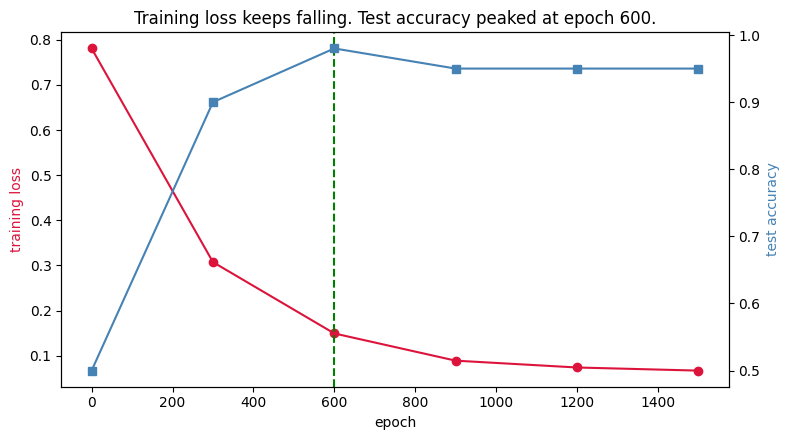

training loss  0.7807 -> 0.0672   still falling
test accuracy  peaked 0.9800 at epoch 600, ended 0.9500

THAT IS OVERFITTING, visible live in the training log.
A falling training loss is NOT proof of an improving model.
The fix is EARLY STOPPING: keep the weights from the best epoch,
not the last one.


In [11]:
# Look carefully at what just happened.
eps  = [h[0] for h in hist]
loss = [h[1] for h in hist]
accs = [h[2] for h in hist]
best = eps[int(np.argmax(accs))]

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(eps, loss, "o-", color="crimson", label="training loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("training loss", color="crimson")
ax2 = ax1.twinx()
ax2.plot(eps, accs, "s-", color="steelblue", label="test accuracy")
ax2.set_ylabel("test accuracy", color="steelblue")
ax1.axvline(best, color="green", ls="--", lw=1.5)
ax1.set_title(f"Training loss keeps falling. Test accuracy peaked at epoch {best}.")
plt.tight_layout(); plt.show()

print(f"training loss  {loss[0]:.4f} -> {loss[-1]:.4f}   still falling")
print(f"test accuracy  peaked {max(accs):.4f} at epoch {best}, ended {accs[-1]:.4f}")
print()
print("THAT IS OVERFITTING, visible live in the training log.")
print("A falling training loss is NOT proof of an improving model.")
print("The fix is EARLY STOPPING: keep the weights from the best epoch,")
print("not the last one.")

In [12]:
# The learning rate: the single most common thing to get wrong.
print(f"{'learning rate':<16}{'final loss':>12}   note")
print("-" * 52)
for lr in [0.001, 0.01, 0.1, 0.5, 5, 50]:
    h, _ = train_net(lr=lr, log=False)
    fl = h[-1][1]
    note = ("too small - very slow" if lr <= 0.01 else
            "about right" if lr <= 0.5 else "unstable / overshooting")
    print(f"{lr:<16}{fl:>12.4f}   {note}")

print("\nIf your loss becomes nan, the learning rate is almost always too high.")

learning rate     final loss   note
----------------------------------------------------


0.001                 0.5291   too small - very slow
0.01                  0.4007   too small - very slow


0.1                   0.3073   about right


0.5                   0.0672   about right
5                     0.3113   unstable / overshooting


50                    5.3983   unstable / overshooting

If your loss becomes nan, the learning rate is almost always too high.


---
# 5. Optimizers

**The optimizer decides how to turn a gradient into an actual weight update.**

| Optimizer | Idea | 🧠 Analogy |
|---|---|---|
| **SGD** | Step down the gradient | Walking downhill one careful step at a time |
| **Momentum** | Keep velocity from previous steps | A **ball rolling** downhill, powering through bumps |
| **RMSProp** | Per-weight step sizes | Small steps on steep ground, big on flat |
| **Adam** | Momentum **and** per-weight steps | The ball with adaptive shoe sizes. **The default** |

In [13]:
print(f"{'optimizer':<20}{'test acc':>10}{'iterations':>13}")
print("-" * 43)
for solver, lr0 in [("adam", .001), ("sgd", .001), ("sgd", .1), ("lbfgs", None)]:
    kw = dict(hidden_layer_sizes=(16, 8), max_iter=2000, random_state=42, solver=solver)
    if lr0: kw["learning_rate_init"] = lr0
    m = MLPClassifier(**kw).fit(Xtr, ytr)
    label = f"{solver}" + (f" lr={lr0}" if lr0 else "")
    print(f"{label:<20}{m.score(Xte, yte):>10.4f}{m.n_iter_:>13}")

print("\nADAM DID NOT WIN. Plain SGD scored higher, and SGD with a larger")
print("learning rate converged in a fifth of the iterations.")
print()
print("So why is Adam the default? Because it is ROBUST: it works")
print("acceptably across a huge range of problems WITHOUT tuning. SGD beat")
print("it here because someone picked a good learning rate for this exact")
print("problem.")
print()
print("And note: all four land within 4 points on 100 test rows - well")
print("inside the noise Session 8 taught you to measure. Treating this")
print("table as a ranking would be a mistake.")

optimizer             test acc   iterations
-------------------------------------------


adam lr=0.001           0.9300          789
sgd lr=0.001            0.9500          538


sgd lr=0.1              0.9300          173
lbfgs                   0.9100          104

ADAM DID NOT WIN. Plain SGD scored higher, and SGD with a larger
learning rate converged in a fifth of the iterations.

So why is Adam the default? Because it is ROBUST: it works
acceptably across a huge range of problems WITHOUT tuning. SGD beat
it here because someone picked a good learning rate for this exact
problem.

And note: all four land within 4 points on 100 test rows - well
inside the noise Session 8 taught you to measure. Treating this
table as a ranking would be a mistake.


In [14]:
# early_stopping=True is the single most valuable setting here.
for es in [False, True]:
    m = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=2000,
                      early_stopping=es, random_state=42).fit(Xtr, ytr)
    print(f"early_stopping={str(es):<6} test {m.score(Xte, yte):.4f}   iterations {m.n_iter_}")

print("\nIt implements exactly the fix for the epoch-600 problem above.")
print("\nA practical starting point:")
print("""
MLPClassifier(
    hidden_layer_sizes=(64, 32),   # start small; grow if underfitting
    activation="relu",             # the default for hidden layers
    solver="adam",                 # the safe optimizer
    learning_rate_init=0.001,      # Adam's usual starting point
    batch_size=32,                 # 32-256 is the practical range
    early_stopping=True,           # <- stop at the validation peak
    validation_fraction=0.1,
    random_state=42,
)""")

early_stopping=False  test 0.9300   iterations 789
early_stopping=True   test 0.4400   iterations 12

It implements exactly the fix for the epoch-600 problem above.

A practical starting point:

MLPClassifier(
    hidden_layer_sizes=(64, 32),   # start small; grow if underfitting
    activation="relu",             # the default for hidden layers
    solver="adam",                 # the safe optimizer
    learning_rate_init=0.001,      # Adam's usual starting point
    batch_size=32,                 # 32-256 is the practical range
    early_stopping=True,           # <- stop at the validation peak
    validation_fraction=0.1,
    random_state=42,
)


---
# 6. From Deep Learning to Generative AI

**Everything you have just built is the foundation of ChatGPT.** The pieces are the same; the scale and one architectural idea are different.

A classifier predicts a **label**. A language model predicts **the next token** — then feeds its own output back in and predicts again.

```text
"The capital of France is"        -> "Paris"
"The capital of France is Paris"  -> "."
"The capital of France is Paris." -> "It"
```

**Generation is prediction, run in a loop.** That is genuinely the whole trick.

🧠 **Predictive text on your phone, scaled up enormously.** Your keyboard suggests the next word from the last two or three. An LLM does the same having read a large fraction of the public internet, considering thousands of previous words at once.

In [15]:
# What is the same, and what is different?
rows = [
    ("Neurons, weights, biases",  "yes",              "yes - identical idea"),
    ("Activation functions",      "ReLU",             "GELU - same role"),
    ("Loss function",             "binary cross-ent", "cross-ent over vocabulary"),
    ("Backpropagation",           "yes",              "yes - identical idea"),
    ("Optimizer",                 "SGD",              "Adam variants"),
    ("Architecture",              "2 dense layers",   "stacked transformer blocks"),
]
print(f"{'':<26}{'your NumPy net':<20}{'GPT-class model'}")
print("-" * 76)
for a_, b_, c_ in rows:
    print(f"{a_:<26}{b_:<20}{c_}")

W1, b1, W2, b2 = weights
n_params = W1.size + b1.size + W2.size + b2.size
print(f"\nyour network      : {n_params:>18,} parameters")
print(f"a small open LLM  : {7_000_000_000:>18,} parameters")
print(f"ratio             : {7_000_000_000 // n_params:>18,}x")
print("\nSame kind of number. Same backpropagation. Just a lot more of them.")
print("\nYou are not missing a magical extra ingredient. You have seen the")
print("whole machine - the difference is SCALE and the ATTENTION mechanism.")

                          your NumPy net      GPT-class model
----------------------------------------------------------------------------
Neurons, weights, biases  yes                 yes - identical idea
Activation functions      ReLU                GELU - same role
Loss function             binary cross-ent    cross-ent over vocabulary
Backpropagation           yes                 yes - identical idea
Optimizer                 SGD                 Adam variants
Architecture              2 dense layers      stacked transformer blocks

your network      :                 33 parameters
a small open LLM  :      7,000,000,000 parameters
ratio             :        212,121,212x

Same kind of number. Same backpropagation. Just a lot more of them.

You are not missing a magical extra ingredient. You have seen the
whole machine - the difference is SCALE and the ATTENTION mechanism.


### What had to be invented

| Component | Purpose |
|---|---|
| **Tokens** | Text split into pieces (roughly ¾ of a word each) |
| **Embeddings** | Each token becomes a vector, so similar words sit near each other |
| **Attention** | Lets the model weigh *which earlier words matter* |
| **Transformer** | The architecture stacking attention and feed-forward layers |
| **Scale** | Billions of parameters, trained on enormous corpora |

🧠 **Attention, by analogy.** *"The trophy did not fit in the suitcase because **it** was too big."* What does "it" refer to? You resolve that by looking back and weighting the earlier words. **That weighting is attention** — and it is why models stopped forgetting the beginning of long passages.

### Generation, in pseudocode

```python
text = "The capital of France is"
for _ in range(20):
    probabilities = model(text)          # a probability for every possible token
    next_token = sample(probabilities)   # pick one
    text = text + next_token             # feed it back in
```

**Temperature**, which you will use in Session 10, is just how sharply you sample from that distribution:

```text
temperature 0.0   always the single most likely token   (repetitive, safe)
temperature 0.7   mostly likely tokens, some variety    (the usual default)
temperature 1.5   adventurous, sometimes incoherent
```

---
# ✅ Before you move on

- [ ] Explaining what a single neuron computes
- [ ] Knowing why XOR needs a hidden layer — and having proved it
- [ ] ReLU hidden, sigmoid for one output, softmax for many
- [ ] Why a network with no activations collapses to a linear model
- [ ] Picking the loss for regression, binary and multi-class problems
- [ ] Why accuracy cannot be a loss function
- [ ] **Having written and trained a neural network in NumPy**
- [ ] Spotting overfitting in a training log and fixing it with early stopping
- [ ] Knowing Adam is the robust default, not always the winner
- [ ] Explaining how next-token prediction turns a network into a text generator

**Exercises, MCQs and tasks:** [Session 9 guide](../sessions/session-09-deep-learning.md)

| | |
|---|---|
| **Previous** | [Session 8 — Model Evaluation & Improvement](../sessions/session-08-evaluation-tuning.md) |
| **Play** | [TensorFlow Playground](https://playground.tensorflow.org/) — watch a network learn in your browser |
| **Stuck?** | [Troubleshooting](../troubleshooting.md) |